# Ximenez Line Map (XML TO CSV)

Map Ximenez line breaks with paragraphs.

In [190]:
import pandas as pd
import numpy as np
import re
pd.set_option('display.max_colwidth', False)

# Load

In [2]:
xml_lines = open("xom-all-flat-mod-pnums.xml").readlines()

# Parse source

In [223]:
els = dict(
    lang = '',
    folio = 0,
    side = 0,
    para = 0,
    lb = 0,
    # lb_n  = '' # Line number as given
)

data = []
ana_list = []

for line in xml_lines:
    
    # Grab column (lang) 
    # Pattern: <div xml:lang="quc" type="column" rend="left half">
    if re.match(r"<div xml:lang", line):
        els['lang'] = line.split('"')[1].split('"')[0]
        els['para'] = 0

    # Grab manuscript
    if re.match(r"^<pb ", line):
        f, s = line.split("xom-")[1].split('"')[0].split('-')
        els['folio'] = int(f[1:])
        els['side'] = int(s[1:])
        els['lb'] = 0

    # Grab paragraph
    if re.match(r"^<p ", line):
        els['para'] += 1

    # Grab line break
    if re.match(r"^<lb n=", line):
        # els['lb_n'] = line.split('<lb n="')[1].split('"')[0]
        els['lb'] += 1
        els['lb_str'] = ' '.join(line.split("/>")[1:]).strip()
        
        # Grab RS elements
        ana_num = 0
        rs = line.split("<rs ")
        if len(rs) > 1:
            for r in rs[1:]:
                ana = r.split('"')[1]  
                ana_num += 1
                # ana_list.append((els['lang'], els['folio'], els['side'], els['para'], els['lb'], els['lb_n'], ana_num, ana))
                ana_list.append((els['lang'], els['folio'], els['side'], els['para'], els['lb'], ana_num, ana))

        data.append(tuple(els.values()))

In [224]:
ana_cols = list(els.keys())[:-1] + ['ana_num', 'ana_id']

In [225]:
TEMA_SEQ = pd.DataFrame(ana_list, columns = ana_cols).set_index(ana_cols[:-1])

In [227]:
TEMA_SEQ.sort_index()

ana_id
lang folio side para lb ana_num                 
quc  1     1    2    6  1        TINAMIT_K'ICHE'
                     10 1        TZ'AQOL        
                        2        B'ITOL         
                     11 1        ALOM           
                        2        K'AJOLOM       
...                               ...           
spa  56    2    100  29 1        NIM_CH'OKOJ    
                     30 1        TINAMIT_K'ICHE'
                     31 1        POPOL_WUJ      
                     34 1        TINAMIT_K'ICHE'
                        2        SANTA_CRUZ     

[6109 rows x 1 columns]

In [228]:
LINE = pd.DataFrame(data, columns=els.keys())
LINE = LINE.set_index(['lang', 'folio', 'side', 'para', 'lb'])

In [229]:
assert LINE.index.has_duplicates == False, "LINE has duplicates"

# Clean line strings

In [230]:
LINE['lb_str_plain'] = LINE.lb_str.str.replace(r"<[^>]+/?>", "", regex=True).str.replace(" –", "–", regex=False)

In [231]:
chars = {
    'Ꜩ': 'Tz',
    'ꜩ': 'tz',
    'ꜫ': "q'",
    'ÿ': 'i', # 'ij' 
}

In [232]:
for char in chars:
    LINE.lb_str_plain = LINE.lb_str_plain.str.replace(char, chars[char], regex=False)

# Extract TEMAs

In [258]:
TEMA_SEQ_QUC_PARA = TEMA_SEQ.loc['quc'].groupby(['para','ana_id']).ana_id.count().unstack(fill_value=0)

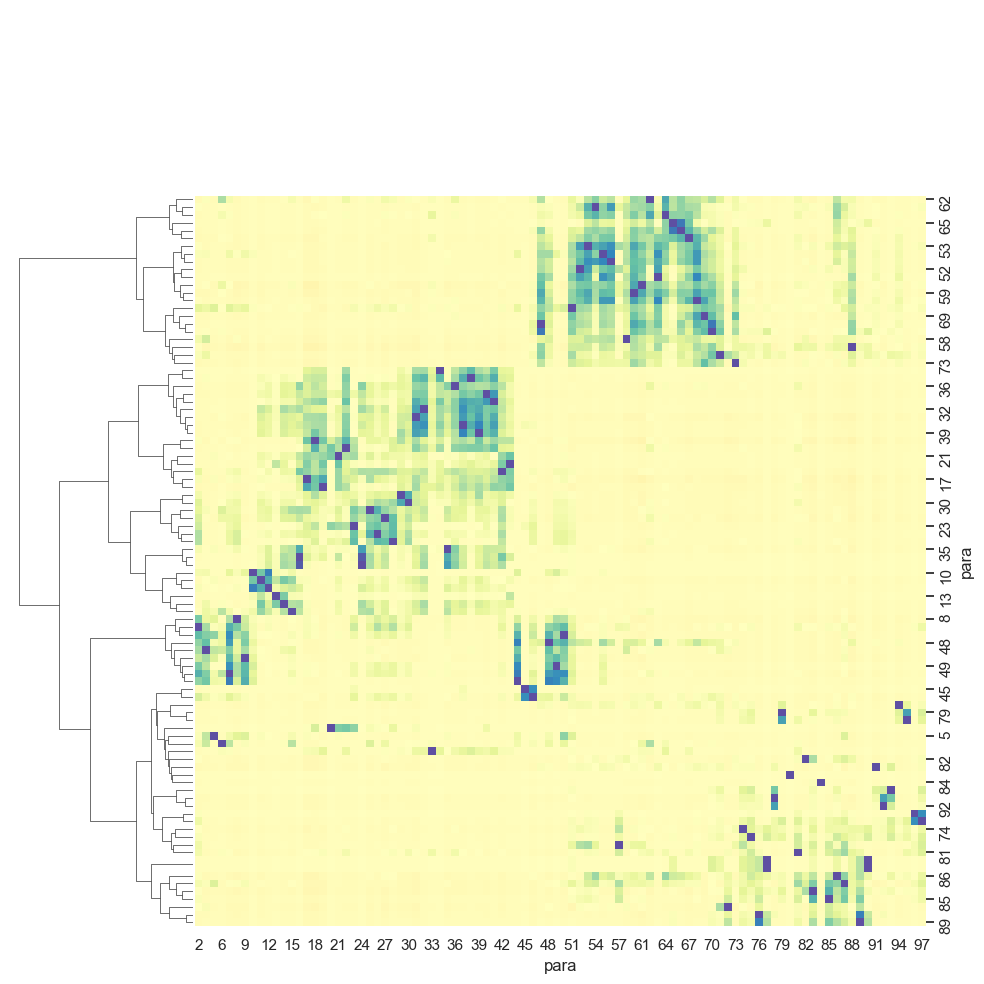

In [260]:
sns.clustermap((TEMA_SEQ_QUC_PARA.T / TEMA_SEQ_QUC_PARA.T.sum()).corr(), col_cluster=False, cmap="Spectral", center=0, metric='euclidean', method='ward', cbar_pos=None);

In [302]:
TEMA_SEQ_QUC_PARA = TEMA_SEQ.loc['quc'].groupby(['para','ana_id']).ana_id.count().to_frame().unstack(fill_value=0)

In [303]:
TEMA_SEQ_QUC_PARA

ana_id                                                       \
ana_id  AB'IX ACHAQ'_IB'OY AJ AJACHE' AJAL_MES AJAL_PUJ AJAL_Q'ANA   
para                                                                 
2       0      0            0  0       0        0        0           
4       0      0            0  0       0        0        0           
5       0      0            0  0       0        0        0           
6       0      0            0  0       0        0        0           
7       0      0            0  0       0        0        0           
...    ..     ..           .. ..      ..       ..       ..           
93      0      0            0  0       0        0        0           
94      0      0            0  0       0        0        0           
95      0      0            0  0       0        0        0           
96      0      0            0  0       0        0        0           
97      0      0            0  0       0        0        0           

                                                         ...             \
ana_id AJAL_TOQ'OB AJAQ_Q'ALEL_NJDOCE AJAW_AJTZIK_WINAQ  ... XUXULIM_JA   
para                                                     ...              
2       0           0                  0                 ...  0           
4       0           0                  0                 ...  0           
5       0           0                  0                 ...  0           
6       0           0                  0                 ...  0           
7       0           0                  0                 ...  0           
...    ..          ..                 ..                 ... ..           
93      0           0                  0                 ...  0           
94      0           0                  0                 ...  0           
95      0           0                  0                 ...  0           
96      0           0                  0                 ...  0           
97      0           0                  0                 ...  0           

                                                                    \
ana_id XUXULUM_JA YA'XKANUL YACHWACH YAK YAKI YAKI_TEPEW YAKOLATAM   
para                                                                 
2       0          0         0        0   0    0          0          
4       0          0         0        0   0    0          0          
5       0          0         0        0   0    0          0          
6       0          0         0        0   0    0          0          
7       0          0         0        0   0    0          0          
...    ..         ..        ..       ..  ..   ..         ..          
93      0          0         0        0   0    0          0          
94      0          0         0        0   0    0          0          
95      0          0         0        0   0    0          0          
96      0          0         0        0   0    0          0          
97      0          0         0        0   0    0          0          

                                                         
ana_id YAKOLATAM_UTZA'M_POP_SAQLATOL YOLKWAT_KITZALKWAT  
para                                                     
2       0                             0                  
4       0                             0                  
5       0                             0                  
6       0                             0                  
7       0                             0                  
...    ..                            ..                  
93      0                             0                  
94      0                             0                  
95      0                             0                  
96      0                             0                  
97      0                             0                  

[94 rows x 452 columns]

In [312]:
TEMA_SEQ_QUC_PARA

ana_id                                                       \
ana_id  AB'IX ACHAQ'_IB'OY AJ AJACHE' AJAL_MES AJAL_PUJ AJAL_Q'ANA   
para                                                                 
2       0      0            0  0       0        0        0           
4       0      0            0  0       0        0        0           
5       0      0            0  0       0        0        0           
6       0      0            0  0       0        0        0           
7       0      0            0  0       0        0        0           
...    ..     ..           .. ..      ..       ..       ..           
93      0      0            0  0       0        0        0           
94      0      0            0  0       0        0        0           
95      0      0            0  0       0        0        0           
96      0      0            0  0       0        0        0           
97      0      0            0  0       0        0        0           

                                                         ...             \
ana_id AJAL_TOQ'OB AJAQ_Q'ALEL_NJDOCE AJAW_AJTZIK_WINAQ  ... XUXULIM_JA   
para                                                     ...              
2       0           0                  0                 ...  0           
4       0           0                  0                 ...  0           
5       0           0                  0                 ...  0           
6       0           0                  0                 ...  0           
7       0           0                  0                 ...  0           
...    ..          ..                 ..                 ... ..           
93      0           0                  0                 ...  0           
94      0           0                  0                 ...  0           
95      0           0                  0                 ...  0           
96      0           0                  0                 ...  0           
97      0           0                  0                 ...  0           

                                                                    \
ana_id XUXULUM_JA YA'XKANUL YACHWACH YAK YAKI YAKI_TEPEW YAKOLATAM   
para                                                                 
2       0          0         0        0   0    0          0          
4       0          0         0        0   0    0          0          
5       0          0         0        0   0    0          0          
6       0          0         0        0   0    0          0          
7       0          0         0        0   0    0          0          
...    ..         ..        ..       ..  ..   ..         ..          
93      0          0         0        0   0    0          0          
94      0          0         0        0   0    0          0          
95      0          0         0        0   0    0          0          
96      0          0         0        0   0    0          0          
97      0          0         0        0   0    0          0          

                                                         
ana_id YAKOLATAM_UTZA'M_POP_SAQLATOL YOLKWAT_KITZALKWAT  
para                                                     
2       0                             0                  
4       0                             0                  
5       0                             0                  
6       0                             0                  
7       0                             0                  
...    ..                            ..                  
93      0                             0                  
94      0                             0                  
95      0                             0                  
96      0                             0                  
97      0                             0                  

[94 rows x 452 columns]

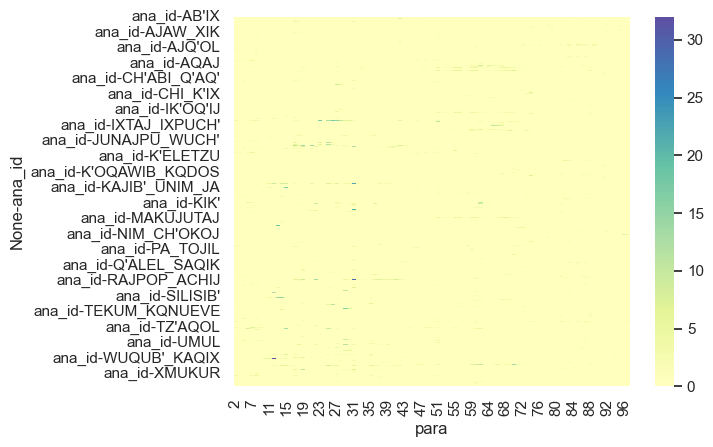

In [311]:
sns.heatmap(TEMA_SEQ_QUC_PARA.T, cmap='Spectral', center=0);

In [276]:
TEMA_SEQ_QUC_PARA.para.values

array([ 2,  2,  2, ..., 97, 97, 97])

In [277]:
# h = len(IDX) // 4
# fig, ax = plt.subplots(figsize=(10, h))
sns.stripplot(x=TEMA_SEQ_QUC_PARA.para.values, y=TEMA_SEQ_QUC_PARA.ana_id.values, ax=ax)

<Axes: xlabel='None', ylabel='ana_id'>

In [256]:
# sns.clustermap(TEMA_SEQ_QUC_PARA.corr())

In [244]:
TEMA = TEMA_SEQ.reset_index().value_counts(['lang','ana_id']).sort_index().to_frame('n')

In [234]:
TEMA

n
lang ana_id                           
quc  AB'IX                          18
     ACHAQ'_IB'OY                   1 
     AJ                             8 
     AJACHE'                        2 
     AJAL_MES                       3 
...                                .. 
spa  YAKI                           4 
     YAKI_TEPEW                     1 
     YAKOLATAM                      1 
     YAKOLATAM_UTZA'M_POP_SAQLATOL  1 
     YOLKWAT_KITZALKWAT             1 

[900 rows x 1 columns]

In [235]:
TEMAX = TEMA.unstack(fill_value=0) #.T.sort_values('quc', ascending=False)
TEMAX.columns = TEMAX.columns.droplevel(0)
TEMAX = TEMAX.T 

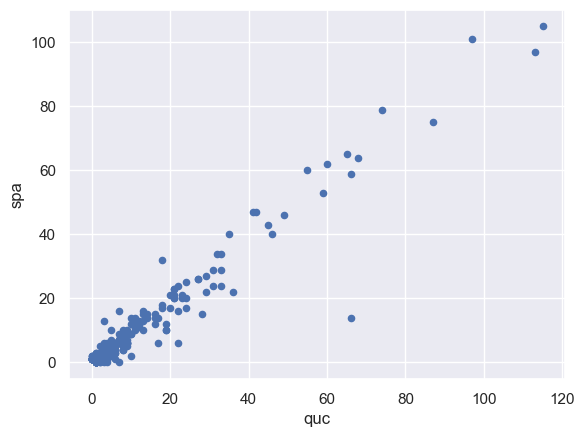

In [236]:
TEMAX.plot.scatter('quc', 'spa');

In [15]:
TEMAX['diff'] = (TEMAX.quc - TEMAX.spa) 

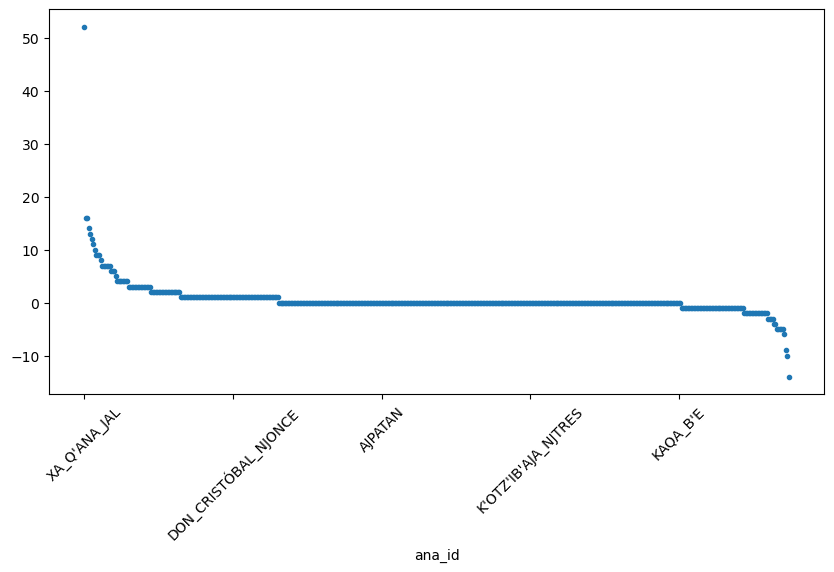

In [16]:
TEMAX.sort_values('diff', ascending=False)['diff'].plot(figsize=(10, 5), rot=45, style='.');

# Visualize

In [17]:
import seaborn as sns # Plotting
import matplotlib.pyplot as plt # Plotting
sns.set_theme(style="darkgrid") # Set seaborn theme

In [48]:
TEMA_SEQ_QUC = TEMA_SEQ.loc['quc']

In [52]:
TEMA_SEQ_QUC

ana_id
folio side para lb lb_n ana_num                 
1     1    2    6  6    1        TINAMIT_K'ICHE'
                10 10   1        TZ'AQOL        
                        2        B'ITOL         
                11 11   1        ALOM           
                        2        K'AJOLOM       
...                               ...           
56    2    97   30 30   1        NIM_CH'OKOJ    
                32 32   1        TINAMIT_K'ICHE'
                33 33   1        POPOL_WUJ      
                35 35   1        TINAMIT_K'ICHE'
                36 36   1        SANTA_CRUZ     

[3189 rows x 1 columns]

In [81]:
min_n = 10

In [82]:
IDX = TEMAX.loc[TEMAX['quc'] > min_n].index

In [83]:
X = TEMA_SEQ_QUC[TEMA_SEQ_QUC.ana_id.isin(IDX)]

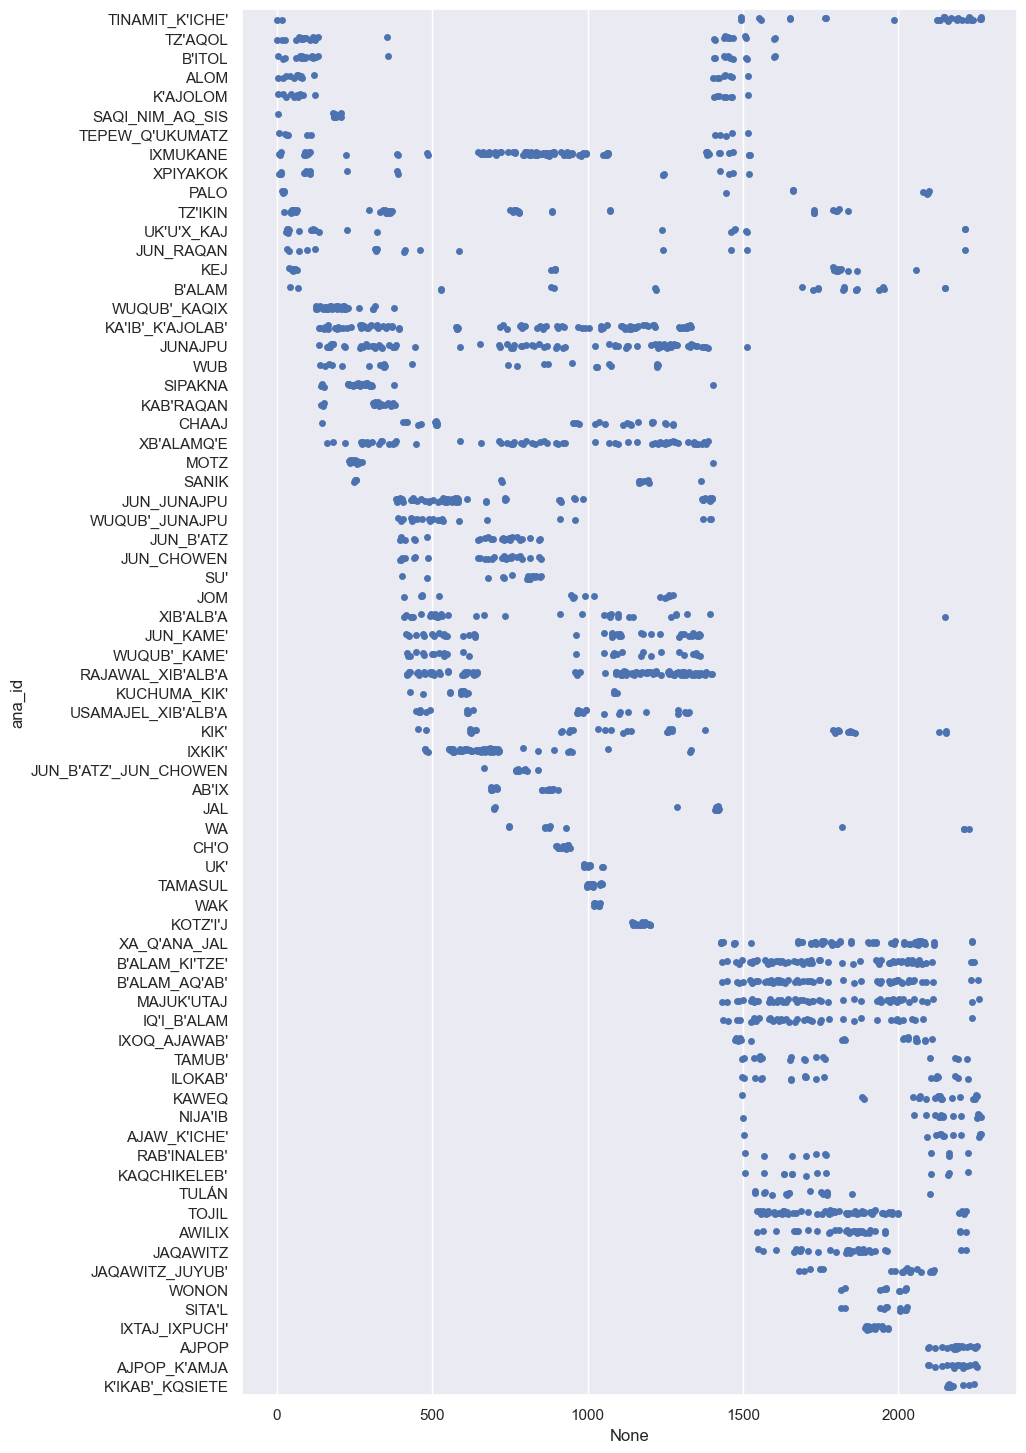

In [85]:
h = len(IDX) // 4
fig, ax = plt.subplots(figsize=(10, h))
sns.stripplot(x=X.reset_index().index, y=X.ana_id, ax=ax);

# Save

In [168]:
for lang in ['spa', 'quc']:
    LINE.loc[lang].to_csv(f"ximenez-{lang}-LINE.csv", index=True, sep='|')
    TEMA_SEQ.loc[lang].to_csv(f"ximenez-{lang}-TEMA_SEQ.csv", index=True, sep='|')
    
TEMAX.to_csv(f"ximenez-{lang}-TEMAX.csv", index=True, sep='|')

# Play

In [143]:
DTM = TEMA_SEQ_QUC.groupby(['folio','side','ana_id']).ana_id.count().unstack(fill_value=0) #apply(lambda x: ' '.join(x)).to_frame()

In [166]:
DTM[IDX].T.corr()

folio              1                   2                   3            \
side               1         2         1         2         1         2   
folio side                                                               
1     1     1.000000  0.282132 -0.020087  0.172737  0.502888  0.848721   
      2     0.282132  1.000000  0.550149  0.274505  0.329737  0.130732   
2     1    -0.020087  0.550149  1.000000  0.031714 -0.043787  0.020138   
      2     0.172737  0.274505  0.031714  1.000000  0.426043  0.022266   
3     1     0.502888  0.329737 -0.043787  0.426043  1.000000  0.270535   
...              ...       ...       ...       ...       ...       ...   
54    2     0.008378 -0.029511  0.180643 -0.106699 -0.104462 -0.109189   
55    1     0.035760 -0.116024 -0.063830 -0.103510 -0.085749 -0.089629   
      2    -0.087801 -0.081392 -0.044778 -0.072613 -0.060154 -0.062876   
56    1    -0.073815 -0.068427 -0.037645 -0.061047 -0.050572 -0.052861   
      2     0.132286 -0.063251 -0.034797 -0.056429 -0.046747 -0.048862   

folio              4             5            ...        52            \
side               1         2   1         2  ...         1         2   
folio side                                    ...                       
1     1     0.737401  0.337900 NaN  0.111389  ...  0.038021 -0.042013   
      2     0.299064  0.476117 NaN  0.062632  ... -0.094891 -0.038946   
2     1     0.291453  0.530763 NaN -0.032595  ... -0.052204 -0.021426   
      2     0.019058  0.260820 NaN  0.031714  ... -0.084657 -0.034745   
3     1     0.221028  0.713024 NaN  0.271481  ... -0.070131 -0.028784   
...              ...       ...  ..       ...  ...       ...       ...   
54    2    -0.034507  0.044274 NaN -0.077760  ...  0.565233 -0.051116   
55    1    -0.092057 -0.094491 NaN -0.063830  ...  0.403819  0.146857   
      2    -0.064579 -0.066287 NaN -0.044778  ...  0.303821  0.163229   
56    1    -0.054293 -0.055728 NaN -0.037645  ... -0.060293 -0.024746   
      2    -0.050186 -0.051512 NaN -0.034797  ...  0.288218 -0.022874   

folio             53                  54                  55            \
side               1         2         1         2         1         2   
folio side                                                               
1     1    -0.063184  0.022463 -0.110573  0.008378  0.035760 -0.087801   
      2    -0.102502 -0.108146  0.095180 -0.029511 -0.116024 -0.081392   
2     1    -0.056391 -0.059496  0.349625  0.180643 -0.063830 -0.044778   
      2    -0.091446 -0.096482 -0.045723 -0.106699 -0.103510 -0.072613   
3     1    -0.075755 -0.079927 -0.075755 -0.104462 -0.085749 -0.060154   
...              ...       ...       ...       ...       ...       ...   
54    2     0.377722  0.678366  0.424290  1.000000  0.322128  0.215892   
55    1     0.448628  0.521775  0.138039  0.322128  1.000000  0.378657   
      2     0.809904  0.639344  0.366218  0.215892  0.378657  1.000000   
56    1     0.130258  0.074691 -0.065129 -0.089809  0.036860  0.117537   
      2     0.210708  0.390969 -0.060202  0.311081  0.326120 -0.003104   

folio             56            
side               1         2  
folio side                      
1     1    -0.073815  0.132286  
      2    -0.068427 -0.063251  
2     1    -0.037645 -0.034797  
      2    -0.061047 -0.056429  
3     1    -0.050572 -0.046747  
...              ...       ...  
54    2    -0.089809  0.311081  
55    1     0.036860  0.326120  
      2     0.117537 -0.003104  
56    1     1.000000  0.373187  
      2     0.373187  1.000000  

[112 rows x 112 columns]

/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


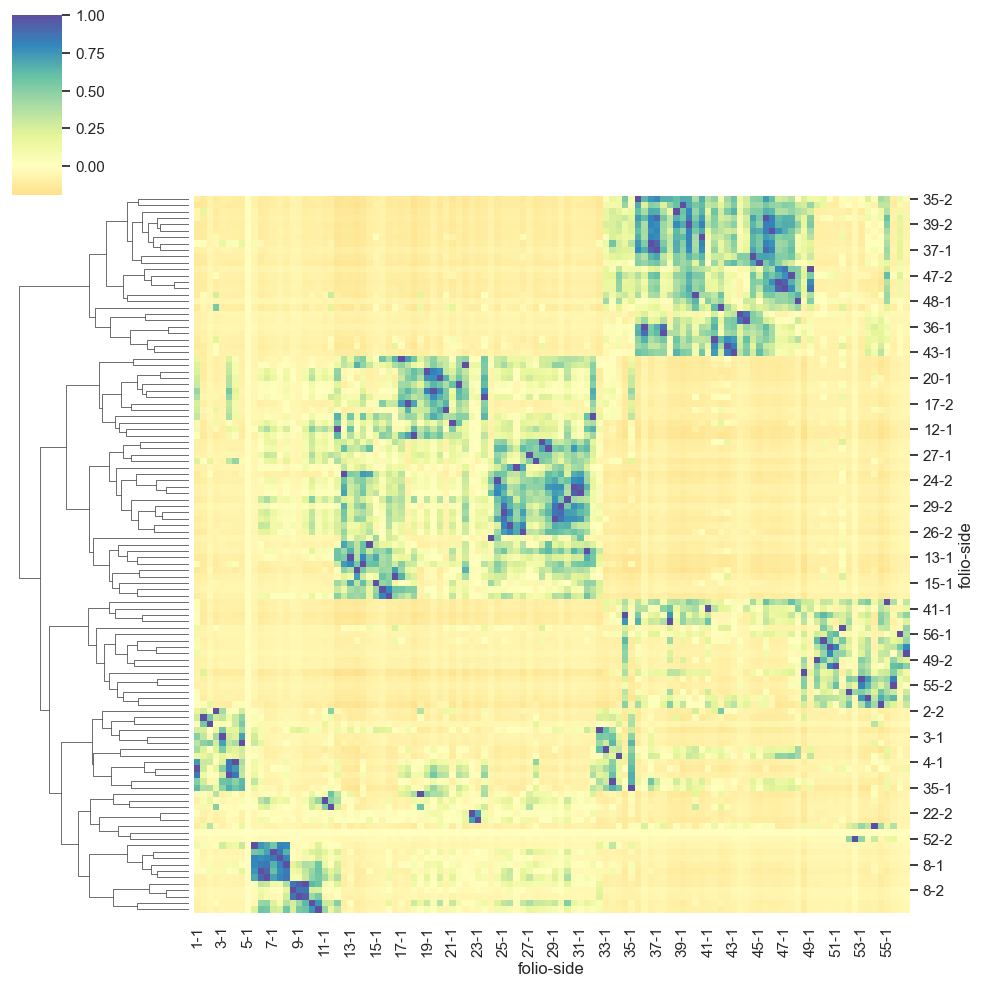

In [167]:
sns.clustermap(DTM[IDX].T.corr().fillna(0), cmap="Spectral", center=0, col_cluster=False)

In [192]:
V = DTM.sum().to_frame('n')
V['df'] = DTM.astype(bool).sum()
V['dp'] = V.df / len(DTM)
V['dh'] = V.dp * np.log2(1/V.dp)

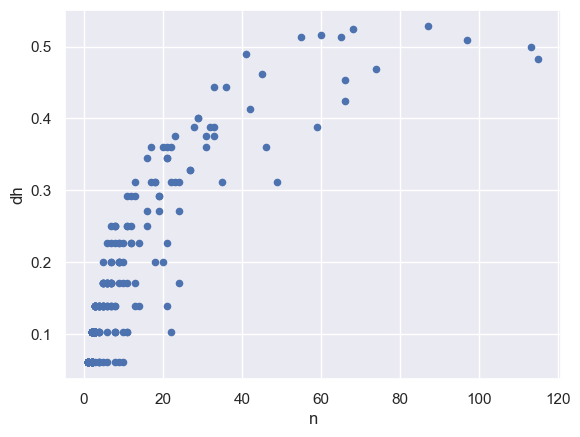

In [195]:
V.plot.scatter('n','dh');

In [217]:
DTM1 = (DTM.T/DTM.T.sum()).T * (np.log2(1/V.dp) + 1)

In [218]:
DTM1

ana_id      AB'IX  ACHAQ'_IB'OY   AJ  AJACHE'  AJAL_MES  AJAL_PUJ  AJAL_Q'ANA  \
folio side                                                                      
1     1     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
      2     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
2     1     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
      2     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
3     1     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
...         ...    ...           ...  ...      ...       ...       ...          
54    2     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
55    1     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
      2     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
56    1     0.0    0.0           0.0  0.0      0.0       0.0       0.0          
      2     0.0    0.0           0.0  0.0      0.0       0.0       0.0          

ana_id      AJAL_TOQ'OB  AJAQ_Q'ALEL_NJDOCE  AJAW_AJTZIK_WINAQ  ...  \
folio side                                                      ...   
1     1     0.0          0.000000            0.000000           ...   
      2     0.0          0.000000            0.000000           ...   
2     1     0.0          0.000000            0.000000           ...   
      2     0.0          0.000000            0.000000           ...   
3     1     0.0          0.000000            0.000000           ...   
...         ...               ...                 ...           ...   
54    2     0.0          0.000000            0.000000           ...   
55    1     0.0          0.000000            0.000000           ...   
      2     0.0          0.000000            0.000000           ...   
56    1     0.0          0.459256            0.200216           ...   
      2     0.0          0.000000            0.000000           ...   

ana_id      XUXULIM_JA  XUXULUM_JA  YA'XKANUL  YACHWACH  YAK  YAKI  \
folio side                                                           
1     1     0.0         0.0         0.0        0.0       0.0  0.0    
      2     0.0         0.0         0.0        0.0       0.0  0.0    
2     1     0.0         0.0         0.0        0.0       0.0  0.0    
      2     0.0         0.0         0.0        0.0       0.0  0.0    
3     1     0.0         0.0         0.0        0.0       0.0  0.0    
...         ...         ...         ...        ...       ...  ...    
54    2     0.0         0.0         0.0        0.0       0.0  0.0    
55    1     0.0         0.0         0.0        0.0       0.0  0.0    
      2     0.0         0.0         0.0        0.0       0.0  0.0    
56    1     0.0         0.0         0.0        0.0       0.0  0.0    
      2     0.0         0.0         0.0        0.0       0.0  0.0    

ana_id      YAKI_TEPEW  YAKOLATAM  YAKOLATAM_UTZA'M_POP_SAQLATOL  \
folio side                                                         
1     1     0.0         0.000000   0.0                             
      2     0.0         0.000000   0.0                             
2     1     0.0         0.000000   0.0                             
      2     0.0         0.000000   0.0                             
3     1     0.0         0.000000   0.0                             
...         ...              ...   ...                             
54    2     0.0         0.000000   0.0                             
55    1     0.0         0.000000   0.0                             
      2     0.0         0.000000   0.0                             
56    1     0.0         0.229628   0.0                             
      2     0.0         0.000000   0.0                             

ana_id      YOLKWAT_KITZALKWAT  
folio side                      
1     1     0.0                 
      2     0.0                 
2     1     0.0                 
      2     0.0                 
3     1     0.0             

/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


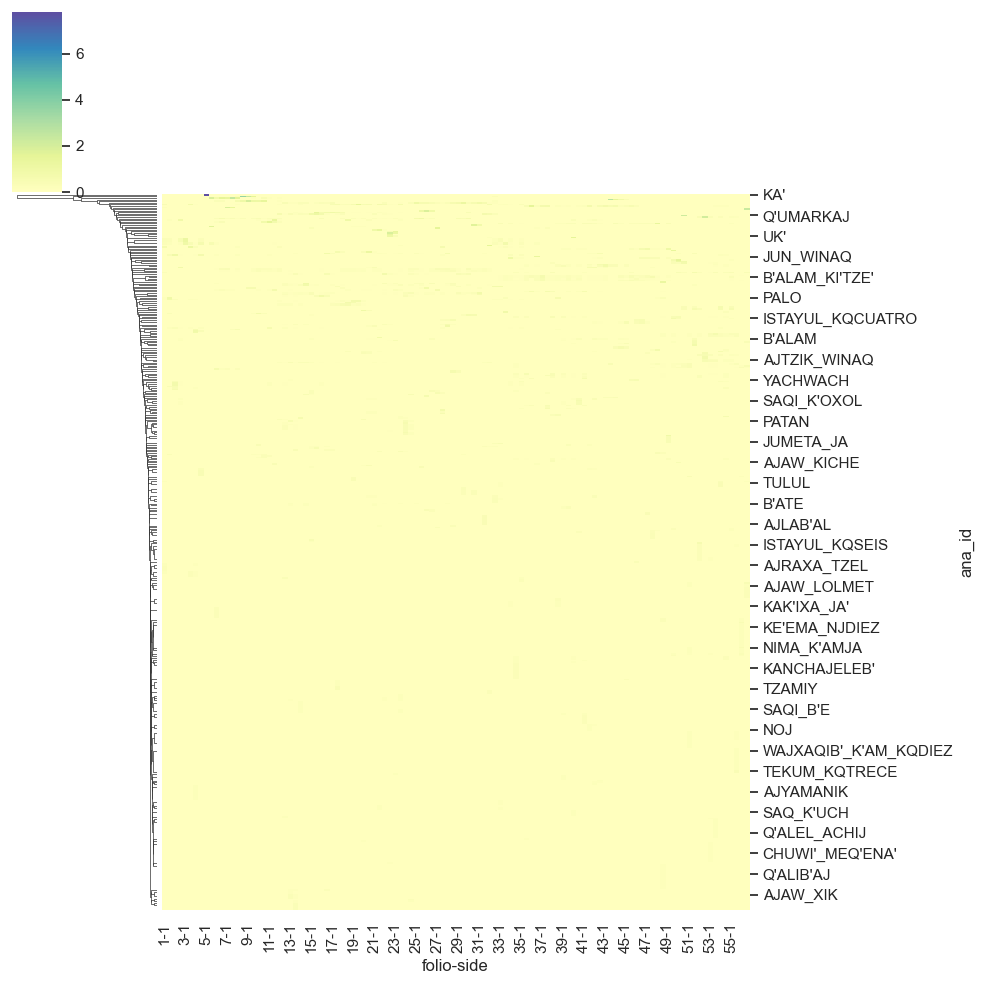

In [220]:
sns.clustermap(DTM1.T, col_cluster=False, cmap="Spectral", center=0)